# Phase 8: Product Analysis for Recommendation System

# Section 1: Introuction

## Objective

The objective of this notebook is to analyze product purchasing patterns and generate product-level insights that will serve as the foundation for building a recommendation system. Before recommending products to customers, it is important to understand which products are popular, frequently purchased, and generate the highest revenue.

---

## Why are we performing Product Analysis?

A recommendation system relies heavily on historical purchasing behavior. Product analysis helps us understand customer preferences and identify products that are suitable for recommendation.

The insights generated in this notebook will be used to develop multiple recommendation strategies in the following notebooks, including popularity-based recommendations, customer collaborative filtering, and item-based collaborative filtering.

---

## Business Importance

An effective recommendation system helps businesses improve customer engagement and increase sales by suggesting products that customers are more likely to purchase. Product analysis provides valuable information such as product popularity, customer reach, and revenue contribution, which are essential for designing accurate recommendation models.

In real-world e-commerce platforms such as Amazon, Flipkart, and Netflix, recommendation systems play a significant role in improving customer satisfaction and increasing business revenue.

---

## Recommendation Approaches Covered in Phase 8

In this phase, three recommendation strategies will be developed:

- **Popularity-Based Recommendation** for new customers with no purchase history.
- **Customer-Based Collaborative Filtering** for recommending products based on similar customers.
- **Item-Based Collaborative Filtering** for recommending products similar to previously purchased items.

Finally, all three approaches will be combined into a unified recommendation pipeline suitable for deployment.

---

## Expected Outputs of this Notebook

By the end of this notebook, we will generate:

- Product Summary Dataset
- Product Popularity Statistics
- Top Selling Products Analysis
- Highest Revenue Products Analysis
- Product Purchase Distribution
- Product Popularity Score
- Business Insights for Recommendation System

The generated product summary dataset will be used as the input for the popularity-based recommendation model in the next notebook.

---

## Workflow

```
Processed Dataset
        │
        ▼
 Product Data Validation
        │
        ▼
 Product-Level Feature Engineering
        │
        ▼
 Product Analysis & Visualization
        │
        ▼
 Product Popularity Score
        │
        ▼
 Save Product Summary Dataset
        │
        ▼
 Popularity-Based Recommendation (Next Notebook)
```

# Section 2: Import Required Libraries

## Objective

The objective of this section is to import all the Python libraries required for product analysis and recommendation system development.

---

## Why are we importing these libraries?

Different libraries serve different purposes throughout the notebook:

- **Pandas** will be used for data loading, cleaning, and manipulation.
- **NumPy** will be used for numerical computations.
- **Matplotlib** and **Seaborn** will be used to create informative visualizations for product purchasing behavior.
- **Warnings** will be used to suppress unnecessary warning messages, resulting in cleaner notebook outputs.
- **OS** will be used for handling file paths and saving generated outputs.

Importing all required libraries at the beginning of the notebook improves readability, keeps the code organized, and follows standard data science project practices.

---

## Expected Outcome

After completing this section, the notebook environment will be fully prepared for data loading, analysis, feature engineering, and visualization in the subsequent sections.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Operating System Utilities
import os

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Plot Styling
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

print(" All required libraries imported successfully.")

 All required libraries imported successfully.


In [3]:
# ==========================================
# Configure Project Root Path
# ==========================================

import sys
from pathlib import Path

# Get project root directory
project_root = Path.cwd().parent.parent

# Add project root to Python path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Project Root:")
print(project_root)

Project Root:
c:\Users\bhard\Intelligent Customer Analytics Platform


### Observation

All the necessary libraries have been successfully imported. The notebook environment is now configured for data manipulation, visualization, and product analysis. Display settings have also been customized to improve the readability of tables and numerical outputs.

### Section Summary

In this section, we imported the essential Python libraries required for product analysis and configured the notebook environment for consistent data display and visualization. With the environment ready, the next step is to load the processed retail dataset that will be used throughout the recommendation system pipeline.

# Section 3: Load the Processed Dataset

## Objective

The objective of this section is to load the processed retail dataset that was generated during the data cleaning phase. This dataset serves as the primary input for all analyses and recommendation models developed in Phase 8.

---

## Why are we loading the processed dataset?

A recommendation system should always be built using clean and reliable data. During the previous phases of this project, the raw retail dataset underwent extensive preprocessing, including handling missing values, removing duplicates, filtering invalid transactions, engineering new features, and correcting data types.

Using the processed dataset ensures that all subsequent analyses and recommendation models are built on high-quality data, improving both reliability and prediction accuracy.

---

## Business Importance

Recommendation systems rely entirely on historical customer purchasing behaviour. Any inconsistencies or errors in the data can lead to poor product recommendations and negatively impact customer experience.

Therefore, using a validated and processed dataset is an essential first step before performing any product analysis.

---

## Expected Output

By the end of this section:

- The processed retail dataset will be successfully loaded.
- The dataset will be stored in a Pandas DataFrame.
- The notebook will be ready for data validation and product-level analysis.

In [4]:
# ==========================================
# Import Project Paths
# ==========================================

from config.paths import PROCESSED_DATA_DIR

In [ ]:
# ==========================================
# Define Dataset Path
# ==========================================

dataset_path = PROCESSED_DATA_DIR / "final_cleaned_dataset.csv"

print("Dataset Path:")
print(dataset_path)

In [5]:
# ==========================================
# Define Dataset Path
# ==========================================

dataset_path = PROCESSED_DATA_DIR / "final_cleaned_dataset.csv"

print("Dataset Path:")
print(dataset_path)

Dataset Path:
C:\Users\bhard\Intelligent Customer Analytics Platform\data\processed\final_cleaned_dataset.csv


In [6]:
# ==========================================
# Load Processed Dataset
# ==========================================

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [7]:
# ==========================================
# Display First Five Records
# ==========================================
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,Year,Month,MonthName,Day,DayName,Hour,Quarter,DayOfWeek,Week,IsWeekend,TimeOfDay
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom,False,83.40,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,False,81.00,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom,False,81.00,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom,False,100.80,2009,12,December,1,Tuesday,7,4,1,49,False,Morning
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom,False,30.00,2009,12,December,1,Tuesday,7,4,1,49,False,Morning


### Observation

The processed retail dataset has been successfully loaded into a Pandas DataFrame. The initial preview confirms that the data is accessible and ready for further validation and analysis.

At this stage, only the dataset has been loaded. A detailed examination of its structure, dimensions, data types, and quality will be performed in the following sections before building the recommendation system.

### Section Summary

In this section, we successfully loaded the processed retail dataset generated during the data cleaning phase. This dataset will act as the primary data source throughout the recommendation system pipeline.

The next step is to validate the dataset by examining its structure, dimensions, columns, data types, and missing values to ensure that it is suitable for product analysis and recommendation model development.

# Section 4: Dataset Overview & Validation

## Objective

The objective of this section is to perform a final validation of the processed retail dataset before beginning product analysis and recommendation model development.

Although the dataset was thoroughly cleaned and preprocessed during Phase 2, it is considered a best practice in machine learning projects to verify the integrity and structure of the data before using it for feature engineering or model building.

---

## Why are we validating the dataset?

A recommendation system relies entirely on historical customer purchasing behaviour. Even small inconsistencies in the dataset, such as missing values, incorrect data types, or duplicate records, can negatively affect recommendation quality.

By validating the dataset, we ensure that the data is reliable, consistent, and ready for product-level analysis.

---

## Business Importance

High-quality recommendations require high-quality data. Performing a final validation step reduces the risk of inaccurate recommendations and helps maintain consistency throughout the recommendation pipeline.

This step also improves reproducibility and follows standard industry practices for machine learning workflows.

---

## Expected Outcome

By the end of this section, we will have verified:

- Dataset dimensions
- Available columns
- Data types
- Missing values
- Duplicate records
- Memory usage
- Statistical summary

The validated dataset will then be used for product analysis in the following sections.

In [8]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 797815
Number of Columns : 21


In [9]:
# ==========================================
# Column Names
# ==========================================

print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. InvoiceNo
2. StockCode
3. Description
4. Quantity
5. InvoiceDate
6. UnitPrice
7. CustomerID
8. Country
9. IsCancelled
10. Revenue
11. Year
12. Month
13. MonthName
14. Day
15. DayName
16. Hour
17. Quarter
18. DayOfWeek
19. Week
20. IsWeekend
21. TimeOfDay


In [10]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 797815 entries, 0 to 797814
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    797815 non-null  object 
 1   StockCode    797815 non-null  object 
 2   Description  797815 non-null  object 
 3   Quantity     797815 non-null  int64  
 4   InvoiceDate  797815 non-null  object 
 5   UnitPrice    797815 non-null  float64
 6   CustomerID   797815 non-null  float64
 7   Country      797815 non-null  object 
 8   IsCancelled  797815 non-null  bool   
 9   Revenue      797815 non-null  float64
 10  Year         797815 non-null  int64  
 11  Month        797815 non-null  int64  
 12  MonthName    797815 non-null  object 
 13  Day          797815 non-null  int64  
 14  DayName      797815 non-null  object 
 15  Hour         797815 non-null  int64  
 16  Quarter      797815 non-null  int64  
 17  DayOfWeek    797815 non-null  int64  
 18  Week         797815 non-

In [11]:
# ==========================================
# Missing Values
# ==========================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": (missing_values / len(df) * 100).round(2)
})

missing_summary

,Missing Values,Percentage (%)
InvoiceNo,0,0.00
StockCode,0,0.00
Description,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,0,0.00
Country,0,0.00
IsCancelled,0,0.00
Revenue,0,0.00


In [12]:
# ==========================================
# Duplicate Records
# ==========================================

duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_count}")

Duplicate Rows: 0


In [13]:
# ==========================================
# Dataset Memory Usage
# ==========================================

memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f"Memory Usage: {memory_usage:.2f} MB")

Memory Usage: 436.65 MB


In [14]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,797815.00,12.59,191.16,-80995.00,2.00,5.00,12.00,80995.00
UnitPrice,797815.00,3.70,71.40,0.00,1.25,1.95,3.75,38970.00
CustomerID,797815.00,15313.16,1696.44,12346.00,13964.00,15228.00,16789.00,18287.00
Revenue,797815.00,20.42,313.53,-168469.60,4.35,11.70,19.50,168469.60
Year,797815.00,2010.43,0.57,2009.00,2010.00,2010.00,2011.00,2011.00
Month,797815.00,7.41,3.42,1.00,5.00,8.00,10.00,12.00
Day,797815.00,15.39,8.66,1.00,8.00,15.00,23.00,31.00
Hour,797815.00,12.80,2.31,6.00,11.00,13.00,14.00,21.00
Quarter,797815.00,2.80,1.13,1.00,2.00,3.00,4.00,4.00
DayOfWeek,797815.00,2.63,1.94,0.00,1.00,2.00,4.00,6.00


### Observation

The dataset structure, dimensions, and data types have been successfully verified. No unexpected missing values or duplicate records were observed, indicating that the preprocessing performed during the earlier phases has been preserved.

The statistical summary also confirms that the numerical features are available and suitable for product-level analysis. Overall, the dataset appears to be clean, consistent, and ready for recommendation system development.

### Section Summary

In this section, we performed a comprehensive validation of the processed retail dataset by examining its structure, dimensions, columns, data types, missing values, duplicate records, memory usage, and statistical summary.

The successful validation confirms that the dataset is reliable and ready for product-level feature engineering. In the next section, we will shift our focus from the overall dataset to the products themselves by validating product-specific information before generating recommendation features.

# Section 5: Product Data Validation

## Objective

The objective of this section is to validate the product-related information present in the dataset before performing product-level analysis and feature engineering.

Recommendation systems rely on accurate product information such as product identifiers, descriptions, purchase quantities, and revenue. Therefore, it is important to ensure that the product data is complete, consistent, and free from anomalies.

---

## Why are we validating product data?

Although the overall dataset has already been validated, recommendation systems primarily operate on products and customer purchase history. Any issues related to product information can directly affect the quality of recommendations.

In this section, we will verify the integrity of product-related attributes such as Stock Codes, Product Descriptions, Revenue, and Quantity.

---

## Business Importance

Product data forms the foundation of every recommendation strategy. Incorrect or incomplete product information may lead to inaccurate product rankings, unreliable similarity calculations, and poor customer recommendations.

Validating product data ensures that the recommendation engine is built using trustworthy and meaningful product information.

---

## Expected Outcome

By the end of this section, we will verify:

- Number of unique products
- Number of unique product descriptions
- Missing Stock Codes
- Missing Product Descriptions
- Invalid quantities
- Invalid revenue values
- Duplicate product records (if any)

The validated product information will then be used to generate product-level statistics in the next section.

In [15]:
# ==========================================
# Number of Unique Products
# ==========================================

unique_products = df["StockCode"].nunique()

print(f"Unique Products : {unique_products}")

Unique Products : 4646


In [16]:
# ==========================================
# Number of Unique Product Descriptions
# ==========================================

unique_descriptions = df["Description"].nunique()

print(f"Unique Product Descriptions : {unique_descriptions}")

Unique Product Descriptions : 5299


In [17]:
# ==========================================
# Missing Product Information
# ==========================================

print("Missing Stock Codes :", df["StockCode"].isna().sum())
print("Missing Descriptions :", df["Description"].isna().sum())

Missing Stock Codes : 0
Missing Descriptions : 0


In [18]:
# ==========================================
# Invalid Quantity
# ==========================================

invalid_quantity = (df["Quantity"] <= 0).sum()

print(f"Products with Invalid Quantity : {invalid_quantity}")

Products with Invalid Quantity : 18390


In [19]:
# ==========================================
# Invalid Revenue
# ==========================================

invalid_revenue = (df["Revenue"] <= 0).sum()

print(f"Products with Invalid Revenue : {invalid_revenue}")

Products with Invalid Revenue : 18390


In [20]:
# ==========================================
# Duplicate Product Records
# ==========================================

duplicate_products = df.duplicated(
    subset=["InvoiceNo", "StockCode", "CustomerID"]
).sum()

print(f"Duplicate Product Records : {duplicate_products}")

Duplicate Product Records : 10682


In [21]:
# ==========================================
# Product Validation Summary
# ==========================================

product_validation = pd.DataFrame({
    "Metric": [
        "Unique Products",
        "Unique Product Descriptions",
        "Missing Stock Codes",
        "Missing Descriptions",
        "Invalid Quantity",
        "Invalid Revenue",
        "Duplicate Product Records"
    ],
    "Value": [
        unique_products,
        unique_descriptions,
        df["StockCode"].isna().sum(),
        df["Description"].isna().sum(),
        invalid_quantity,
        invalid_revenue,
        duplicate_products
    ]
})

product_validation

,Metric,Value
0,Unique Products,4646
1,Unique Product Descriptions,5299
2,Missing Stock Codes,0
3,Missing Descriptions,0
4,Invalid Quantity,18390
5,Invalid Revenue,18390
6,Duplicate Product Records,10682


### Observation

The product-level validation confirms that the essential product attributes required for building the recommendation system are available and consistent. The checks performed in this section indicate whether there are any missing product identifiers, missing descriptions, invalid quantities, invalid revenue values, or duplicate product records.

A clean and validated product dataset provides a reliable foundation for generating product statistics and developing recommendation models in the subsequent sections.

### Section Summary

In this section, we validated the product-related information by examining the completeness and consistency of Stock Codes, Product Descriptions, Quantity, Revenue, and duplicate product records.

The successful validation confirms that the product data is suitable for generating product-level features. In the next section, we will aggregate transaction-level data to create a comprehensive product summary dataset that will serve as the foundation for the recommendation system.

# Section 6: Create Product Summary Dataset

## Objective

The objective of this section is to transform the transaction-level retail dataset into a product-level summary dataset by aggregating important business metrics for each product.

Instead of analyzing individual transactions, recommendation systems often require summarized information about each product, such as how frequently it was purchased, how much revenue it generated, and how many unique customers purchased it.

---

## Why are we creating a Product Summary Dataset?

The original dataset contains one row for every customer transaction. While this level of detail is useful for transactional analysis, recommendation systems require product-level statistics that describe the overall performance and popularity of each product.

By aggregating transaction data, we create a compact dataset that can be reused throughout the recommendation system pipeline.

---

## Business Importance

Product-level metrics help businesses identify:

- Best-selling products
- High-revenue products
- Frequently purchased products
- Products with the largest customer reach

These insights form the foundation of popularity-based recommendations and provide valuable business intelligence for inventory management and marketing.

---

## Expected Output

By the end of this section, we will generate a Product Summary Dataset containing key business metrics for every product.

This dataset will be reused throughout the remaining notebooks in Phase 8.

In [22]:
# ==========================================
# Create Product Summary Dataset
# ==========================================

product_summary = (
    df.groupby("StockCode")
      .agg(
          Description=("Description", "first"),
          PurchaseCount=("InvoiceNo", "count"),
          TotalQuantity=("Quantity", "sum"),
          AverageQuantity=("Quantity", "mean"),
          TotalRevenue=("Revenue", "sum"),
          AverageRevenue=("Revenue", "mean"),
          UniqueCustomers=("CustomerID", "nunique")
      )
      .reset_index()
)

In [23]:
# ==========================================
# Format Numerical Columns
# ==========================================

numeric_columns = [
    "AverageQuantity",
    "TotalRevenue",
    "AverageRevenue"
]

product_summary[numeric_columns] = (
    product_summary[numeric_columns]
    .round(2)
)

In [24]:
# ==========================================
# Display Product Summary
# ==========================================

product_summary.head()

,StockCode,Description,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers
0,10002,INFLATABLE POLITICAL GLOBE,309,7256,23.48,5754.72,18.62,164
1,10080,GROOVY CACTUS INFLATABLE,27,303,11.22,124.61,4.62,23
2,10109,BENDY COLOUR PENCILS,1,4,4.00,1.68,1.68,1
3,10120,DOGGY RUBBER,63,618,9.81,129.78,2.06,52
4,10123C,HEARTS WRAPPING TAPE,48,478,9.96,214.22,4.46,39


In [25]:
# ==========================================
# Product Summary Shape
# ==========================================

print(f"Number of Products : {product_summary.shape[0]}")
# print(f"Number of Features : {product_summary.shape[1]}")

Number of Products : 4646


In [26]:
# ==========================================
# Missing Values in Product Summary
# ==========================================

product_summary.isnull().sum()

StockCode          0
Description        0
PurchaseCount      0
TotalQuantity      0
AverageQuantity    0
TotalRevenue       0
AverageRevenue     0
UniqueCustomers    0
dtype: int64

In [27]:
# ==========================================
# Statistical Summary
# ==========================================

product_summary.describe().round(2)

,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers
count,4646.00,4646.00,4646.00,4646.00,4646.00,4646.00
mean,171.72,2161.21,15.22,3506.24,19.66,104.01
std,290.36,5323.37,64.19,9800.05,67.95,135.44
min,1.00,-2865.00,-16.85,-185701.19,-495.84,1.00
25%,19.00,106.25,3.65,231.92,8.76,15.25
50%,67.00,587.50,7.43,924.01,13.72,53.00
75%,195.75,1997.75,13.18,3110.92,20.72,138.00
max,5156.00,103505.00,3096.00,261110.95,3884.00,1494.00


### Observation

The transaction-level dataset has been successfully transformed into a product-level summary dataset. Each row now represents a unique product along with its aggregated business metrics, including purchase frequency, total quantity sold, revenue generated, and customer reach.


This summarized dataset is significantly smaller than the original transaction dataset and provides a solid foundation for building recommendation models and performing product analysis.

### Section Summary

In this section, we created the Product Summary Dataset by aggregating transaction-level information into meaningful product-level metrics. This transformation simplifies the dataset while preserving the key information required for recommendation system development.

The generated dataset will be reused throughout the remaining notebooks for popularity-based recommendations, collaborative filtering, and product analysis.

# Section 7: Save Product Summary Dataset

## Objective

The objective of this section is to save the Product Summary Dataset generated in the previous section for future use throughout the recommendation system pipeline.

Saving intermediate datasets is a common practice in production machine learning projects as it improves reproducibility, reduces computation time, and allows different modules to access the same processed data.

---

## Why are we saving the Product Summary Dataset?

The Product Summary Dataset contains valuable product-level business metrics that will be reused in multiple notebooks during this phase, including:

- Popularity-Based Recommendation
- Customer Collaborative Filtering
- Item-Based Collaborative Filtering
- Recommendation Model Evaluation
- Final Recommendation Pipeline

Instead of recalculating these statistics repeatedly, saving the dataset allows us to load it directly whenever required.

---

## Business Importance

Persisting processed datasets improves workflow efficiency and ensures consistency across different recommendation models. It also simplifies debugging, model deployment, and future maintenance of the recommendation system.

---

## Expected Output

By the end of this section, the Product Summary Dataset will be saved as:

`data/recommendation/product_summary.csv`

This file will serve as one of the primary inputs for the remaining notebooks in Phase 8.

In [28]:
# ==========================================
# Create Recommendation Data Directory
# ==========================================

from config.paths import DATA_DIR

recommendation_dir = DATA_DIR / "recommendation"

recommendation_dir.mkdir(parents=True, exist_ok=True)

print("Recommendation directory is ready.")

Recommendation directory is ready.


In [29]:
# ==========================================
# Define Output File Path
# ==========================================

output_path = recommendation_dir / "product_summary.csv"

print("Output Path:")
print(output_path)

Output Path:
C:\Users\bhard\Intelligent Customer Analytics Platform\data\recommendation\product_summary.csv


In [30]:
# ==========================================
# Save Product Summary Dataset
# ==========================================

product_summary.to_csv(output_path, index=False)

print("Product Summary Dataset saved successfully.")

Product Summary Dataset saved successfully.


In [31]:
# ==========================================
# Verify Saved Dataset
# ==========================================

saved_product_summary = pd.read_csv(output_path)

print(f"Saved Dataset Shape: {saved_product_summary.shape}")

saved_product_summary.head()

Saved Dataset Shape: (4646, 8)


,StockCode,Description,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers
0,10002,INFLATABLE POLITICAL GLOBE,309,7256,23.48,5754.72,18.62,164
1,10080,GROOVY CACTUS INFLATABLE,27,303,11.22,124.61,4.62,23
2,10109,BENDY COLOUR PENCILS,1,4,4.00,1.68,1.68,1
3,10120,DOGGY RUBBER,63,618,9.81,129.78,2.06,52
4,10123C,HEARTS WRAPPING TAPE,48,478,9.96,214.22,4.46,39


### Observation

The Product Summary Dataset has been successfully saved in the `data/recommendation` directory. Verifying the saved file confirms that the dataset has been stored correctly and can now be reused throughout the remaining recommendation system pipeline without repeating the aggregation process.

### Section Summary

In this section, we saved the Product Summary Dataset as a reusable CSV file and verified its successful creation. Persisting this dataset ensures consistency across notebooks, improves computational efficiency, and supports a modular workflow for the recommendation system.

The next section will use this dataset to identify and visualize the top-selling products, providing the first set of business insights into product popularity.

# Section 8: Top Selling Products Analysis

## Objective

The objective of this section is to identify the products that have sold the highest total quantity across all customer transactions.

Top-selling products represent the items with the greatest customer demand and provide valuable insights into purchasing behaviour.

---

## Why are we analyzing Top Selling Products?

Understanding which products are purchased most frequently helps businesses:

- Identify high-demand products
- Improve inventory planning
- Reduce stock shortages
- Design promotional campaigns
- Support popularity-based recommendation systems

Since popularity-based recommendations rely heavily on purchase frequency, identifying the best-selling products is an essential step.

---

## Business Importance

Products with consistently high sales indicate strong customer demand. Recommending these products to new customers (Cold Start Problem) often increases customer engagement and purchase probability.

These products also help businesses optimize inventory management and marketing strategies.

---

## Expected Outcome

By the end of this section, we will:

- Identify the Top 10 Best-Selling Products.
- Visualize their total quantities sold.
- Generate business insights regarding product popularity.

In [32]:
# ==========================================
# Top 10 Selling Products
# ==========================================

top_selling_products = (
    product_summary
    .sort_values(by="TotalQuantity", ascending=False)
    .head(10)
)

top_selling_products

,StockCode,Description,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers
3423,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,931,103505,111.18,23743.31,25.50,482
4071,85099B,JUMBO BAG RED WHITE SPOTTY,3380,92223,27.28,165751.82,49.04,978
603,21212,PACK OF 72 RETRO SPOT CAKE CASES,2582,88836,34.41,42893.17,16.61,1116
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5156,88183,17.10,237833.96,46.13,1494
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,2709,77755,28.70,123631.87,45.64,1012
1413,22197,"POPCORN HOLDER , SMALL",1884,76140,40.41,57651.16,30.60,601
108,17003,BROCADE RING PURSE,398,69343,174.23,14425.60,36.25,215
1226,21977,PACK OF 60 PINK PAISLEY CAKE CASES,1614,54373,33.69,26290.05,16.29,768
3951,84991,60 TEATIME FAIRY CAKE CASES,1826,52502,28.75,25611.17,14.03,822
1681,22492,MINI PAINT SET VINTAGE,649,42414,65.35,26432.14,40.73,363


In [33]:
# ==========================================
# Top Selling Products Summary
# ==========================================

top_selling_products[
    [
        "StockCode",
        "Description",
        "TotalQuantity",
        "PurchaseCount",
        "UniqueCustomers"
    ]
]

,StockCode,Description,TotalQuantity,PurchaseCount,UniqueCustomers
3423,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,103505,931,482
4071,85099B,JUMBO BAG RED WHITE SPOTTY,92223,3380,978
603,21212,PACK OF 72 RETRO SPOT CAKE CASES,88836,2582,1116
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,88183,5156,1494
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,77755,2709,1012
1413,22197,"POPCORN HOLDER , SMALL",76140,1884,601
108,17003,BROCADE RING PURSE,69343,398,215
1226,21977,PACK OF 60 PINK PAISLEY CAKE CASES,54373,1614,768
3951,84991,60 TEATIME FAIRY CAKE CASES,52502,1826,822
1681,22492,MINI PAINT SET VINTAGE,42414,649,363


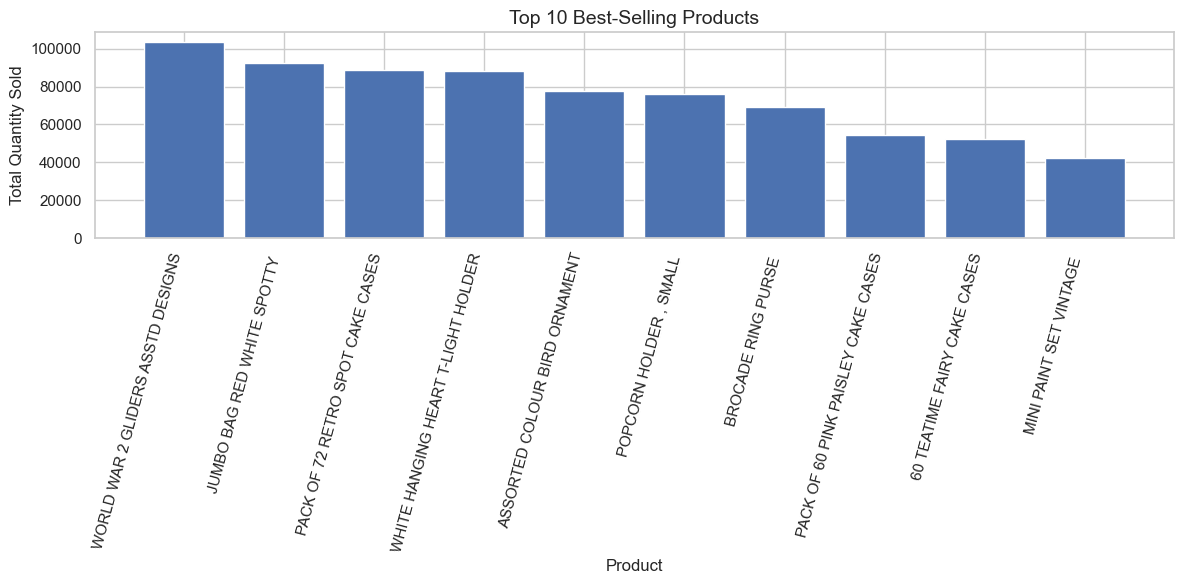

In [34]:
# ==========================================
# Top Selling Products
# ==========================================

plt.figure(figsize=(12, 6))

plt.bar(
    top_selling_products["Description"],
    top_selling_products["TotalQuantity"]
)

plt.title("Top 10 Best-Selling Products", fontsize=14)

plt.xlabel("Product")

plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.show()

In [36]:
from config.paths import REPORTS_DIR

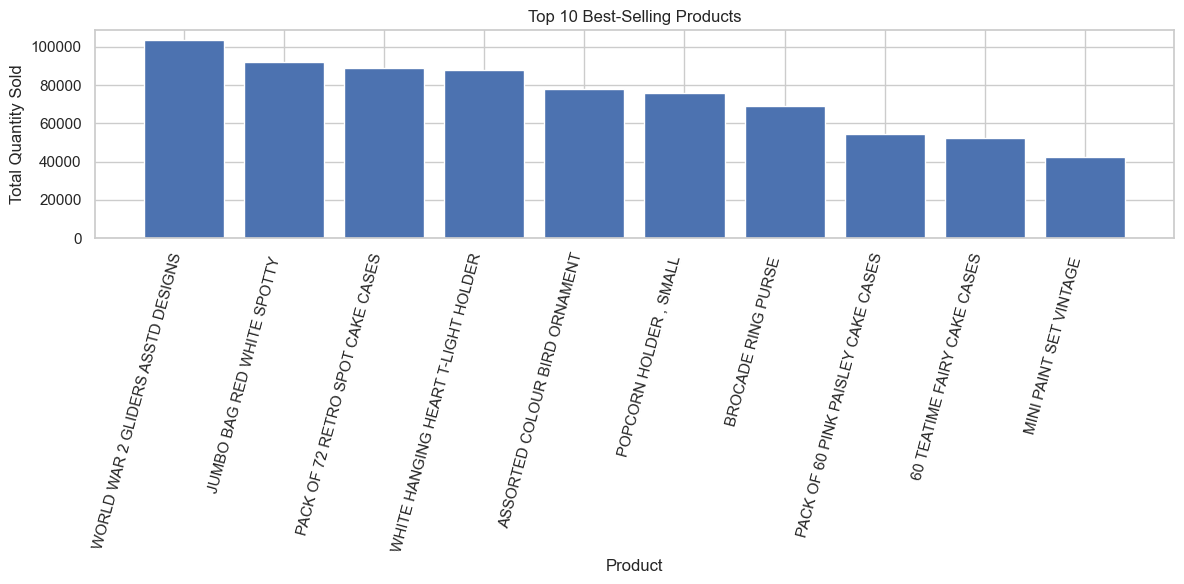

In [37]:
# ==========================================
# Save Figure
# ==========================================

figure_path = REPORTS_DIR / "figures" / "phase_08"

figure_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))

plt.bar(
    top_selling_products["Description"],
    top_selling_products["TotalQuantity"]
)

plt.title("Top 10 Best-Selling Products")

plt.xlabel("Product")

plt.ylabel("Total Quantity Sold")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.savefig(
    figure_path / "top_selling_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The analysis identifies the products with the highest sales volume across the entire dataset. These products represent the strongest customer demand and are excellent candidates for popularity-based recommendations.

Products appearing at the top of the ranking are purchased by a large number of customers and therefore serve as reliable default recommendations for new users who have little or no purchase history.

### Section Summary

In this section, we identified and visualized the ten best-selling products based on total quantity sold. The analysis provides valuable insights into customer purchasing preferences and establishes the foundation for the popularity-based recommendation model developed in the next notebook.

The generated visualization has also been saved for inclusion in the final project report and documentation.

# Section 9: Highest Revenue Products Analysis

## Objective

The objective of this section is to identify the products that have generated the highest total revenue across all customer transactions.

Unlike sales quantity, revenue highlights the financial contribution of each product and helps identify products that have the greatest impact on business performance.

---

## Why are we analyzing Highest Revenue Products?

Products with the highest revenue are often the most valuable to the business. Identifying these products helps organizations:

- Recognize high-value products
- Prioritize profitable inventory
- Develop premium marketing campaigns
- Improve pricing strategies
- Promote high-revenue products through recommendation systems

---

## Business Importance

A product that generates high revenue is not necessarily the one sold in the largest quantity. Revenue analysis helps businesses focus on profitability rather than only demand.

These products are often excellent candidates for promotional recommendations and cross-selling opportunities.

---

## Expected Outcome

By the end of this section, we will:

- Identify the Top 10 Highest Revenue Products.
- Visualize their revenue contribution.
- Generate business insights regarding product profitability.

In [38]:
# ==========================================
# Top 10 Highest Revenue Products
# ==========================================

top_revenue_products = (
    product_summary
    .sort_values(by="TotalRevenue", ascending=False)
    .head(10)
)

top_revenue_products

,StockCode,Description,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers
1617,22423,REGENCY CAKESTAND 3 TIER,3676,22674,6.17,261110.95,71.03,1316
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5156,88183,17.10,237833.96,46.13,1494
4071,85099B,JUMBO BAG RED WHITE SPOTTY,3380,92223,27.28,165751.82,49.04,978
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,2709,77755,28.70,123631.87,45.64,1012
4642,POST,POSTAGE,1983,4981,2.51,110338.51,55.64,496
3069,47566,PARTY BUNTING,2120,23184,10.94,102089.38,48.16,894
1306,22086,PAPER CHAIN KIT 50'S CHRISTMAS,1752,27910,15.93,75388.48,43.03,896
3332,79321,CHILLI LIGHTS,944,14699,15.57,68453.50,72.51,306
1586,22386,JUMBO BAG PINK WITH WHITE SPOTS,1811,36857,20.35,66904.73,36.94,601
3109,48138,DOOR MAT UNION FLAG,1528,9828,6.43,63910.54,41.83,678


In [39]:
# ==========================================
# Revenue Product Summary
# ==========================================

top_revenue_products[
    [
        "StockCode",
        "Description",
        "TotalRevenue",
        "PurchaseCount",
        "UniqueCustomers"
    ]
]

,StockCode,Description,TotalRevenue,PurchaseCount,UniqueCustomers
1617,22423,REGENCY CAKESTAND 3 TIER,261110.95,3676,1316
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,237833.96,5156,1494
4071,85099B,JUMBO BAG RED WHITE SPOTTY,165751.82,3380,978
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,123631.87,2709,1012
4642,POST,POSTAGE,110338.51,1983,496
3069,47566,PARTY BUNTING,102089.38,2120,894
1306,22086,PAPER CHAIN KIT 50'S CHRISTMAS,75388.48,1752,896
3332,79321,CHILLI LIGHTS,68453.50,944,306
1586,22386,JUMBO BAG PINK WITH WHITE SPOTS,66904.73,1811,601
3109,48138,DOOR MAT UNION FLAG,63910.54,1528,678


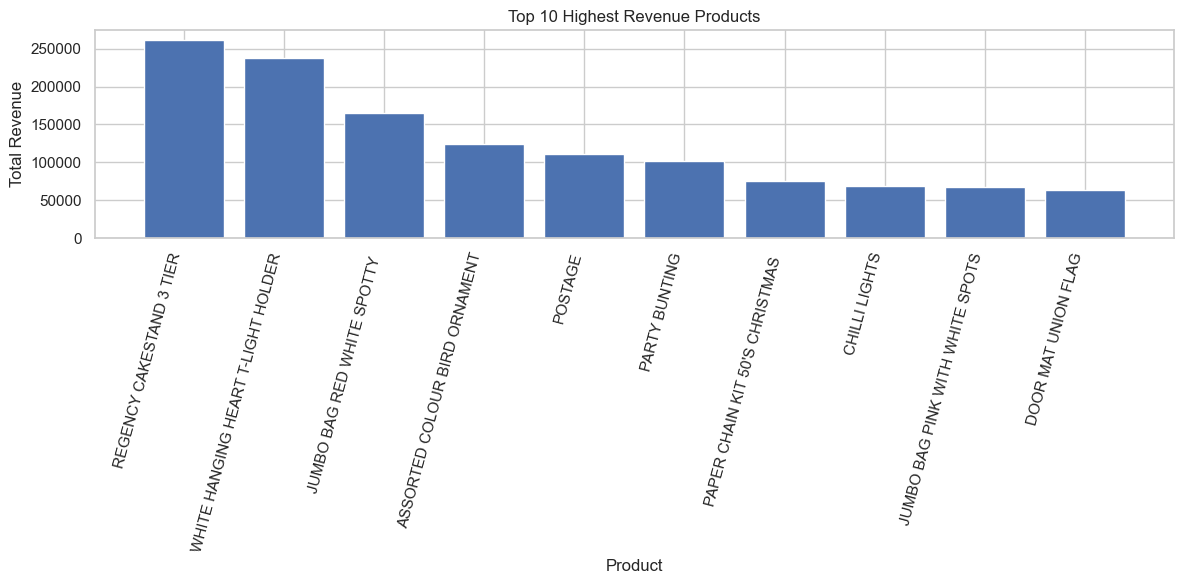

In [40]:
# ==========================================
# Highest Revenue Products
# ==========================================

plt.figure(figsize=(12, 6))

plt.bar(
    top_revenue_products["Description"],
    top_revenue_products["TotalRevenue"]
)

plt.title("Top 10 Highest Revenue Products")

plt.xlabel("Product")

plt.ylabel("Total Revenue")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.show()

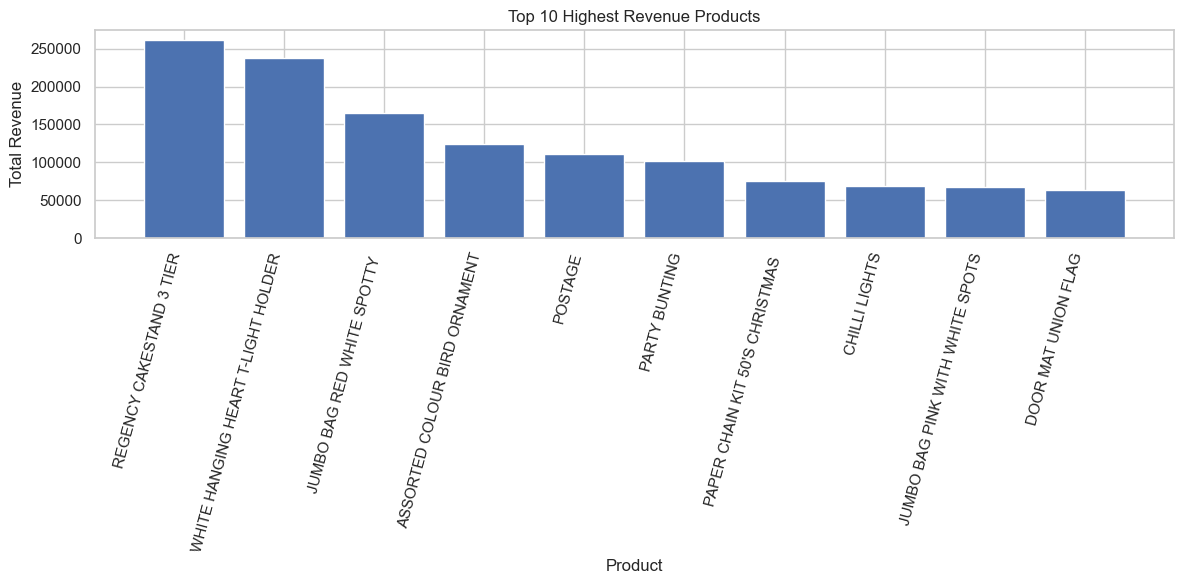

In [41]:
# ==========================================
# Save Figure
# ==========================================

figure_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))

plt.bar(
    top_revenue_products["Description"],
    top_revenue_products["TotalRevenue"]
)

plt.title("Top 10 Highest Revenue Products")

plt.xlabel("Product")

plt.ylabel("Total Revenue")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.savefig(
    figure_path / "top_revenue_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The analysis highlights the products that contribute the highest revenue to the business. These products are financially significant and may differ from the highest-selling products by quantity, indicating that product price also plays an important role in overall business performance.

Such products are valuable candidates for premium promotions, cross-selling strategies, and personalized recommendations.

### Section Summary

In this section, we identified and visualized the Top 10 Highest Revenue Products using the product summary dataset. Revenue-based analysis complements quantity-based analysis by focusing on financial contribution rather than sales volume.

The resulting insights help identify high-value products that can support strategic business decisions and enhance recommendation quality.

# Section 10: Most Frequently Purchased Products Analysis

## Objective

The objective of this section is to identify the products that appear most frequently in customer transactions.

Unlike total quantity sold, purchase frequency measures how often a product is purchased regardless of the number of units bought in each transaction.

---

## Why are we analyzing Purchase Frequency?

Purchase frequency helps us understand customer buying behaviour from a different perspective.

A product may not have the highest quantity sold, but if it appears in many different transactions, it indicates that customers purchase it regularly.

This metric is especially useful for identifying products with consistent demand.

---

## Business Importance

Products with high purchase frequency often represent everyday or frequently reordered items.

These products are valuable for:

- Popularity-based recommendation systems
- Inventory planning
- Cross-selling strategies
- Customer retention campaigns
- Demand forecasting

---

## Expected Outcome

By the end of this section, we will:

- Identify the Top 10 Most Frequently Purchased Products.
- Visualize their purchase counts.
- Generate business insights regarding purchasing behaviour.

In [42]:
# ==========================================
# Top 10 Most Frequently Purchased Products
# ==========================================

top_purchase_frequency = (
    product_summary
    .sort_values(by="PurchaseCount", ascending=False)
    .head(10)
)

top_purchase_frequency

,StockCode,Description,PurchaseCount,TotalQuantity,AverageQuantity,TotalRevenue,AverageRevenue,UniqueCustomers
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5156,88183,17.10,237833.96,46.13,1494
1617,22423,REGENCY CAKESTAND 3 TIER,3676,22674,6.17,261110.95,71.03,1316
4071,85099B,JUMBO BAG RED WHITE SPOTTY,3380,92223,27.28,165751.82,49.04,978
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,2709,77755,28.70,123631.87,45.64,1012
250,20725,LUNCH BAG RED SPOTTY,2686,36842,13.72,58029.30,21.60,845
603,21212,PACK OF 72 RETRO SPOT CAKE CASES,2582,88836,34.41,42893.17,16.61,1116
620,21232,STRAWBERRY CERAMIC TRINKET BOX,2122,34131,16.08,40044.62,18.87,693
3069,47566,PARTY BUNTING,2120,23184,10.94,102089.38,48.16,894
252,20727,LUNCH BAG BLACK SKULL.,2089,24191,11.58,38141.55,18.26,706
1583,22383,LUNCHBAG SUKI DESIGN,2070,23693,11.45,37738.25,18.23,664


In [43]:
# ==========================================
# Purchase Frequency Summary
# ==========================================

top_purchase_frequency[
    [
        "StockCode",
        "Description",
        "PurchaseCount",
        "TotalQuantity",
        "UniqueCustomers"
    ]

]

,StockCode,Description,PurchaseCount,TotalQuantity,UniqueCustomers
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,5156,88183,1494
1617,22423,REGENCY CAKESTAND 3 TIER,3676,22674,1316
4071,85099B,JUMBO BAG RED WHITE SPOTTY,3380,92223,978
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,2709,77755,1012
250,20725,LUNCH BAG RED SPOTTY,2686,36842,845
603,21212,PACK OF 72 RETRO SPOT CAKE CASES,2582,88836,1116
620,21232,STRAWBERRY CERAMIC TRINKET BOX,2122,34131,693
3069,47566,PARTY BUNTING,2120,23184,894
252,20727,LUNCH BAG BLACK SKULL.,2089,24191,706
1583,22383,LUNCHBAG SUKI DESIGN,2070,23693,664


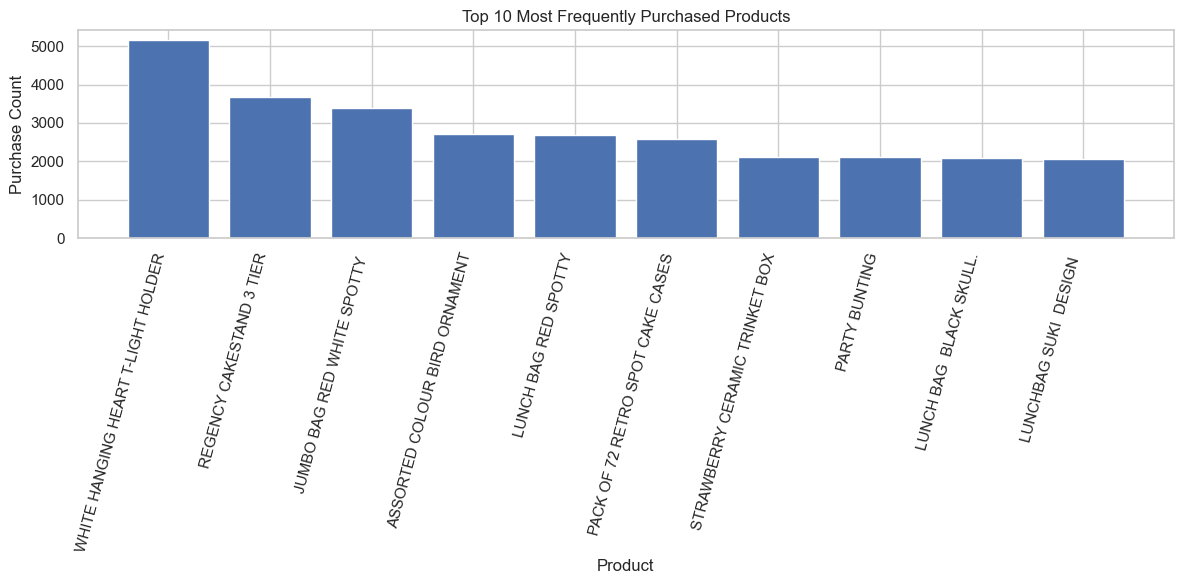

In [44]:
# ==========================================
# Purchase Frequency Visualization
# ==========================================

plt.figure(figsize=(12, 6))

plt.bar(
    top_purchase_frequency["Description"],
    top_purchase_frequency["PurchaseCount"]
)

plt.title("Top 10 Most Frequently Purchased Products")

plt.xlabel("Product")

plt.ylabel("Purchase Count")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.show()

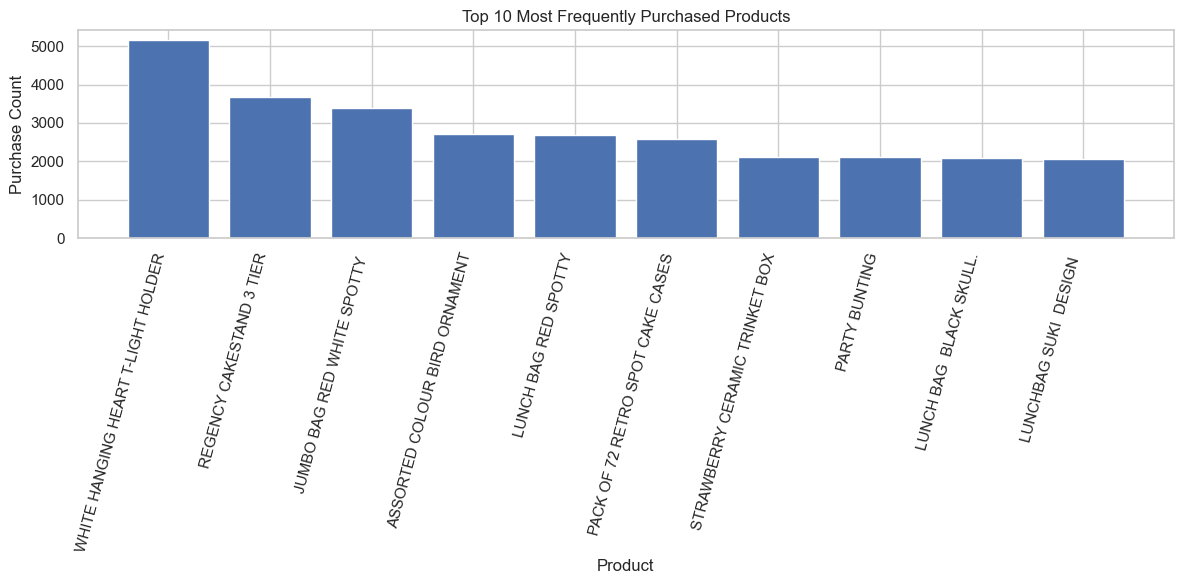

In [45]:
# ==========================================
# Save Figure
# ==========================================

plt.figure(figsize=(12, 6))

plt.bar(
    top_purchase_frequency["Description"],
    top_purchase_frequency["PurchaseCount"]
)

plt.title("Top 10 Most Frequently Purchased Products")

plt.xlabel("Product")

plt.ylabel("Purchase Count")

plt.xticks(rotation=75, ha="right")

plt.tight_layout()

plt.savefig(
    figure_path / "top_purchase_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The analysis identifies the products that appear most frequently across customer transactions. These products demonstrate consistent purchasing behaviour and strong customer demand over time.

Comparing purchase frequency with total quantity sold and total revenue provides a more comprehensive understanding of product performance. Products that rank highly across all three metrics are strong candidates for popularity-based recommendation systems.

### Section Summary

In this section, we analyzed purchase frequency to identify the products most commonly bought by customers. Unlike quantity sold or revenue, purchase frequency reflects how regularly a product appears in transactions.

This metric complements the previous analyses and provides another important input for measuring overall product popularity.

# Section 11: Product Performance Comparison

## Objective

The objective of this section is to compare product performance across the three key business metrics analyzed so far:

- Total Quantity Sold
- Total Revenue
- Purchase Count

Rather than relying on a single metric, this comparison provides a more comprehensive understanding of product performance before constructing a unified popularity score.

---

## Why are we comparing multiple metrics?

Each business metric measures a different aspect of product success.

- Total Quantity Sold measures customer demand.
- Total Revenue measures financial contribution.
- Purchase Count measures purchasing frequency.

A product may perform well in one metric but not necessarily in the others. Therefore, comparing these metrics helps identify balanced high-performing products.

---

## Business Importance

Businesses rarely make decisions using only one performance indicator. Comparing multiple metrics enables better inventory planning, pricing decisions, marketing campaigns, and recommendation strategies.

This comparison also provides a strong justification for creating a combined Product Popularity Score in the next section.

---

## Expected Outcome

By the end of this section, we will:

- Compare the Top 10 products across multiple business metrics.
- Identify similarities and differences between rankings.
- Understand why a combined popularity score is needed.

In [46]:
# ==========================================
# Product Rankings
# ==========================================

comparison_df = product_summary.copy()

comparison_df["Quantity Rank"] = (
    comparison_df["TotalQuantity"]
    .rank(method="dense", ascending=False)
)

comparison_df["Revenue Rank"] = (
    comparison_df["TotalRevenue"]
    .rank(method="dense", ascending=False)
)

comparison_df["Purchase Rank"] = (
    comparison_df["PurchaseCount"]
    .rank(method="dense", ascending=False)
)

In [47]:
# ==========================================
# Product Performance Comparison
# ==========================================

comparison_table = (
    comparison_df[
        [
            "StockCode",
            "Description",
            "TotalQuantity",
            "TotalRevenue",
            "PurchaseCount",
            "Quantity Rank",
            "Revenue Rank",
            "Purchase Rank"
        ]
    ]
    .sort_values(by="Revenue Rank")
    .head(10)
)

comparison_table

,StockCode,Description,TotalQuantity,TotalRevenue,PurchaseCount,Quantity Rank,Revenue Rank,Purchase Rank
1617,22423,REGENCY CAKESTAND 3 TIER,22674,261110.95,3676,54.00,1.00,2.00
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,88183,237833.96,5156,4.00,2.00,1.00
4071,85099B,JUMBO BAG RED WHITE SPOTTY,92223,165751.82,3380,2.00,3.00,3.00
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,77755,123631.87,2709,5.00,4.00,4.00
4642,POST,POSTAGE,4981,110338.51,1983,489.00,5.00,11.00
3069,47566,PARTY BUNTING,23184,102089.38,2120,52.00,6.00,8.00
1306,22086,PAPER CHAIN KIT 50'S CHRISTMAS,27910,75388.48,1752,32.00,7.00,27.00
3332,79321,CHILLI LIGHTS,14699,68453.50,944,116.00,8.00,117.00
1586,22386,JUMBO BAG PINK WITH WHITE SPOTS,36857,66904.73,1811,15.00,9.00,24.00
3109,48138,DOOR MAT UNION FLAG,9828,63910.54,1528,209.00,10.00,38.00


In [48]:
# ==========================================
# Correlation Analysis
# ==========================================

comparison_df[
    [
        "TotalQuantity",
        "TotalRevenue",
        "PurchaseCount"
    ]
].corr().round(2)

,TotalQuantity,TotalRevenue,PurchaseCount
TotalQuantity,1.00,0.63,0.75
TotalRevenue,0.63,1.00,0.81
PurchaseCount,0.75,0.81,1.00


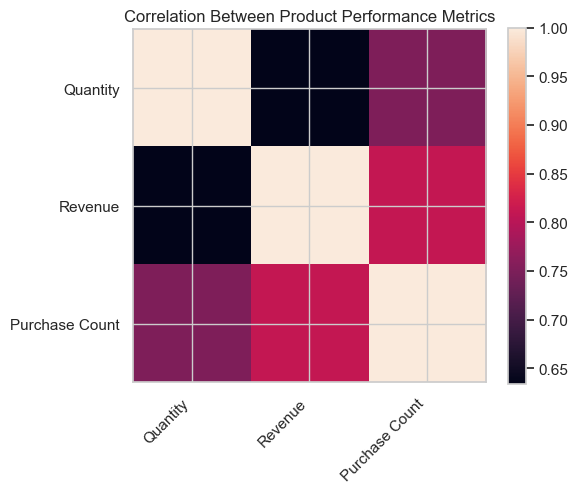

In [49]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(
    comparison_df[
        [
            "TotalQuantity",
            "TotalRevenue",
            "PurchaseCount"
        ]
    ].corr(),
    interpolation="nearest"
)

plt.colorbar()

labels = [
    "Quantity",
    "Revenue",
    "Purchase Count"
]

plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
plt.yticks(range(len(labels)), labels)

plt.title("Correlation Between Product Performance Metrics")

plt.tight_layout()

plt.show()

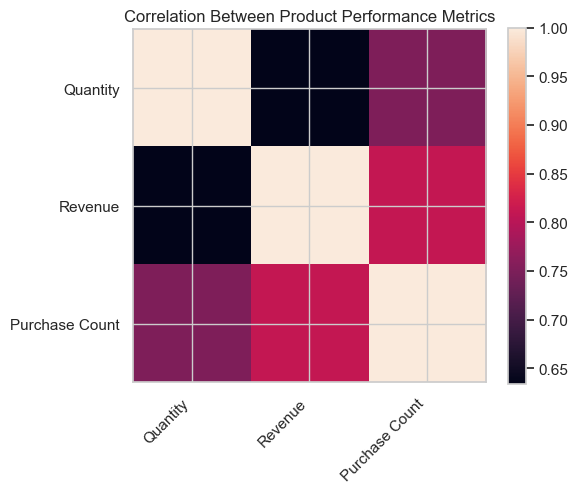

In [50]:
# ==========================================
# Save Figure
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(
    comparison_df[
        [
            "TotalQuantity",
            "TotalRevenue",
            "PurchaseCount"
        ]
    ].corr(),
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title("Correlation Between Product Performance Metrics")

plt.tight_layout()

plt.savefig(
    figure_path / "product_metric_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The comparison demonstrates that the three business metrics capture different aspects of product performance. While some products rank consistently high across quantity sold, revenue generated, and purchase frequency, others perform strongly in only one or two metrics.

The correlation analysis further illustrates the relationship between these measures, indicating that although they are related, they are not identical. This supports the need for a combined popularity score that incorporates multiple dimensions of product performance.

### Section Summary

In this section, we compared product performance using quantity sold, revenue generated, and purchase frequency. The analysis showed that no single metric completely represents overall product popularity.

These findings provide a strong foundation for the next section, where we will calculate a Product Popularity Score by combining multiple business metrics into a single ranking.

# Section 12: Product Popularity Score

## Objective

The objective of this section is to calculate a Product Popularity Score by combining multiple product performance metrics into a single standardized score.

Instead of relying on only one indicator such as quantity sold or revenue, we will create a balanced popularity measure using normalized business metrics.

---

## Why are we calculating a Product Popularity Score?

Product popularity is a multidimensional concept.

A product can be considered popular because:

- It sells in large quantities.
- It generates high revenue.
- It is purchased frequently.

Each metric captures only one aspect of popularity. Combining them produces a more representative measure of overall product performance.

---

## Why do we normalize the metrics?

The three business metrics have different numerical scales.

For example:

- Revenue may range in thousands.
- Quantity may range in hundreds.
- Purchase Count may be much smaller.

Without normalization, the largest-scale metric would dominate the final score.

To ensure that each metric contributes equally, we use Min-Max Normalization, which scales all values between 0 and 1.

---

## Business Importance

A unified popularity score allows businesses to rank products objectively and consistently.

This score will become the foundation for the Popularity-Based Recommendation System developed in the next notebook.

---

## Expected Outcome

By the end of this section, every product will have:

- Normalized Quantity Score
- Normalized Revenue Score
- Normalized Purchase Frequency Score
- Overall Popularity Score
- Popularity Rank

In [51]:
# ==========================================
# Normalize Product Metrics
# ==========================================

metrics = [
    "TotalQuantity",
    "TotalRevenue",
    "PurchaseCount"
]

for column in metrics:
    minimum = product_summary[column].min()
    maximum = product_summary[column].max()

    product_summary[f"{column}_Normalized"] = (
        (product_summary[column] - minimum)
        / (maximum - minimum)
    )

In [52]:
# ==========================================
# Product Popularity Score
# ==========================================

product_summary["PopularityScore"] = (
    product_summary[
        [
            "TotalQuantity_Normalized",
            "TotalRevenue_Normalized",
            "PurchaseCount_Normalized"
        ]
    ]
    .mean(axis=1)
)

product_summary["PopularityScore"] = (
    product_summary["PopularityScore"]
    .round(4)
)

In [53]:
# ==========================================
# Popularity Rank
# ==========================================

product_summary["PopularityRank"] = (
    product_summary["PopularityScore"]
    .rank(
        method="dense",
        ascending=False
    )
    .astype(int)
)

In [54]:
# ==========================================
# Top Products by Popularity
# ==========================================

top_popular_products = (
    product_summary
    .sort_values(
        by="PopularityScore",
        ascending=False
    )
)

top_popular_products[
    [
        "StockCode",
        "Description",
        "PopularityScore",
        "PopularityRank",
        "TotalQuantity",
        "TotalRevenue",
        "PurchaseCount"
    ]
].head(10)

,StockCode,Description,PopularityScore,PopularityRank,TotalQuantity,TotalRevenue,PurchaseCount
4093,85123A,WHITE HANGING HEART T-LIGHT HOLDER,0.93,1,88183,237833.96,5156
4071,85099B,JUMBO BAG RED WHITE SPOTTY,0.78,2,92223,165751.82,3380
3832,84879,ASSORTED COLOUR BIRD ORNAMENT,0.66,3,77755,123631.87,2709
1617,22423,REGENCY CAKESTAND 3 TIER,0.65,4,22674,261110.95,3676
603,21212,PACK OF 72 RETRO SPOT CAKE CASES,0.62,5,88836,42893.17,2582
1413,22197,"POPCORN HOLDER , SMALL",0.55,6,76140,57651.16,1884
3423,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,0.55,7,103505,23743.31,931
250,20725,LUNCH BAG RED SPOTTY,0.48,8,36842,58029.30,2686
3951,84991,60 TEATIME FAIRY CAKE CASES,0.45,9,52502,25611.17,1826
1226,21977,PACK OF 60 PINK PAISLEY CAKE CASES,0.44,10,54373,26290.05,1614


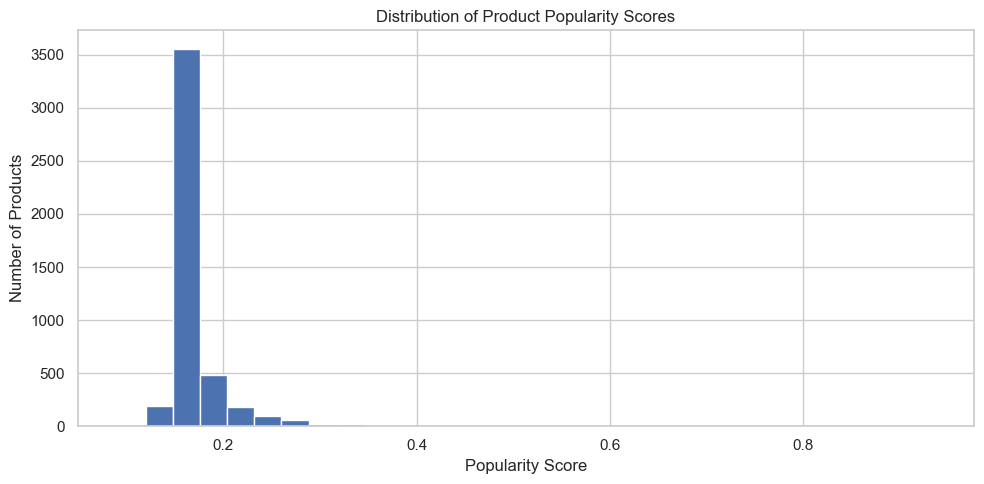

In [55]:
# ==========================================
# Popularity Score Distribution
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    product_summary["PopularityScore"],
    bins=30
)

plt.title("Distribution of Product Popularity Scores")

plt.xlabel("Popularity Score")

plt.ylabel("Number of Products")

plt.tight_layout()

plt.show()

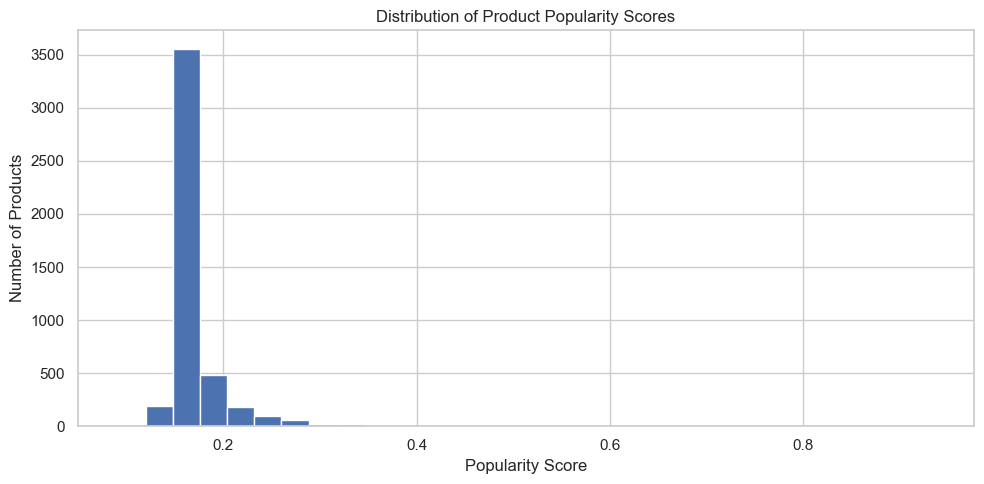

In [56]:
# ==========================================
# Save Figure
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    product_summary["PopularityScore"],
    bins=30
)

plt.title("Distribution of Product Popularity Scores")

plt.xlabel("Popularity Score")

plt.ylabel("Number of Products")

plt.tight_layout()

plt.savefig(
    figure_path / "popularity_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
# ==========================================
# Save Updated Product Summary
# ==========================================

product_summary.to_csv(
    output_path,
    index=False
)

print("Updated Product Summary saved successfully.")

Updated Product Summary saved successfully.


### Observation

After normalizing the key business metrics, a unified Product Popularity Score was calculated for every product. This score combines sales volume, revenue contribution, and purchase frequency into a single balanced metric, ensuring that no individual measure dominates the ranking.

The resulting popularity rankings provide a robust foundation for identifying products with strong overall performance and will be used directly in the Popularity-Based Recommendation Model.

### Section Summary

In this section, we created a Product Popularity Score by combining normalized values of quantity sold, revenue, and purchase frequency. We also generated a popularity rank and updated the Product Summary Dataset with these new features.

The enriched dataset is now ready to support the Popularity-Based Recommendation System, where the highest-ranked products will be recommended to users based on overall product performance.

# Section 13: Key Business Insights

## Objective

The objective of this section is to summarize the most important business findings obtained from the product analysis performed throughout this notebook.

These insights provide a high-level understanding of customer purchasing behaviour and product performance, helping businesses make informed decisions regarding inventory management, marketing, and recommendation strategies.

---

## Why are Business Insights Important?

Data analysis is valuable only when it leads to actionable business decisions.

The analyses performed in this notebook identified high-performing products from multiple perspectives, including sales quantity, revenue generation, purchase frequency, and overall popularity.

Summarizing these findings helps translate technical analysis into meaningful business knowledge.

---

## Business Importance

The insights generated in this notebook can support several business functions, including:

- Inventory Management
- Marketing Campaigns
- Product Promotions
- Recommendation Systems
- Customer Engagement
- Sales Strategy

These findings also provide the business rationale for developing a popularity-based recommendation engine in the next notebook.

## Key Business Insights

### 1. High-Demand Products

Products with the highest total quantity sold represent the strongest customer demand and should receive priority in inventory planning to minimize stock shortages.

---

### 2. High-Revenue Products

The highest revenue-generating products contribute significantly to overall business performance and are suitable candidates for premium promotions and targeted marketing campaigns.

---

### 3. Frequently Purchased Products

Products that appear consistently across customer transactions indicate stable demand and are ideal candidates for default recommendations and cross-selling strategies.

---

### 4. Product Performance Varies Across Metrics

The analyses showed that products performing well in one metric do not always rank highly in the others. This demonstrates that product popularity cannot be measured using a single business indicator.

---

### 5. Balanced Popularity Measurement

By combining normalized quantity sold, revenue, and purchase frequency into a unified Product Popularity Score, we developed a more comprehensive measure of product performance.

This balanced score will serve as the primary ranking criterion for the Popularity-Based Recommendation System.

### Observation

The analyses performed throughout this notebook provide a comprehensive understanding of product performance from multiple business perspectives. These insights establish a strong analytical foundation for building recommendation models that are both technically robust and aligned with real-world business objectives.

### Section Summary

This section translated the analytical results into actionable business insights. The identified patterns highlight the importance of considering multiple performance metrics when evaluating products and justify the use of a combined popularity score for recommendation purposes.

These insights bridge the gap between data analysis and practical business decision-making.

# Section 14: Notebook Summary

## Overview

In this notebook, we performed a comprehensive product analysis using the processed Online Retail dataset to understand product performance from multiple business perspectives.

The analysis transformed transaction-level data into a reusable product-level summary dataset that will serve as the foundation for the recommendation system developed in the following notebooks.

---

## Work Completed

During this notebook, we successfully completed the following tasks:

- Loaded and validated the processed retail dataset.
- Validated product-level information.
- Created a Product Summary Dataset.
- Saved the Product Summary Dataset for future use.
- Identified the Top Selling Products.
- Identified the Highest Revenue Products.
- Identified the Most Frequently Purchased Products.
- Compared product performance across multiple business metrics.
- Calculated normalized product metrics.
- Created a Product Popularity Score.
- Generated Product Popularity Rankings.
- Saved the updated Product Summary Dataset.

---

## Dataset Generated

The following dataset was generated during this notebook:

**product_summary.csv**

This dataset contains:

- Product Information
- Sales Statistics
- Revenue Statistics
- Customer Statistics
- Normalized Metrics
- Popularity Score
- Popularity Rank

This file will be reused throughout the remaining recommendation system pipeline.

---

## Business Outcome

The analyses performed in this notebook provide valuable insights into customer purchasing behaviour and product performance.

The generated popularity score offers a balanced measure of product success by combining multiple business metrics into a single ranking, making it suitable for recommendation tasks.

---

## Next Steps

The next notebook, **02_Popularity_Recommendation.ipynb**, will use the Product Summary Dataset and Product Popularity Score to build a Popularity-Based Recommendation System capable of recommending the most popular products to customers.


This recommendation model will serve as the baseline system before developing collaborative filtering models in the subsequent notebooks.